In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
df = pd.read_parquet('./artifacts/canonical_user_year_choices.parquet', engine='fastparquet')
df = df[df['year'] >= 2015].copy()
df.drop(columns = ['split'], inplace=True)

df.rename(columns = {'price_final': 'price'}, inplace=True)
df.to_parquet('consumer_choices.parquet', engine='fastparquet')
df.to_parquet('demand_1.parquet', engine='fastparquet')
df.head()


,user_id,year,choice,brand,parent_asin,product_title,price,average_rating,waterproof_flag,party_flag,voice_assistant_flag,purchase_dt
0,AE224SS3CBECXN5SGPRY5WW7TU4Q,2015,JBL,jbl,B00GAJ2OK4,JBL Flip 2 Portable Wireless Speaker (Black),55.00,4.5,False,False,False,2015-05-24 23:39:26
1,AE22AIEZGF67Z65KRCQGPLGVDZRQ,2015,Other,unknown,B00KWU863Q,"Logitech X300 Mobile Wireless Stereo Speaker, ...",39.95,4.3,False,False,False,2015-01-28 21:14:58
2,AE22ZDVFW5T2Y37QBP2W6HP2LMWA,2015,Other,creative,B003N9PJDI,Creative D200 Bluetooth Speaker,49.99,4.4,False,False,False,2015-03-17 01:35:18
3,AE23CACEREJI2O6X7RWTNRF2NUDQ,2015,Bose,bose,B01AS57B0I,Bose SoundLink Color Bluetooth Speaker (Blue),99.99,4.6,False,False,False,2015-02-14 18:14:52
4,AE23GFJX7BXK77S7C34AHWXPCJEQ,2015,Other,jawbone,B0087BDWBI,"Jawbone Jambox Bluetooth Speaker, Diamond Blac...",69.99,4.3,False,False,False,2015-06-15 19:54:38


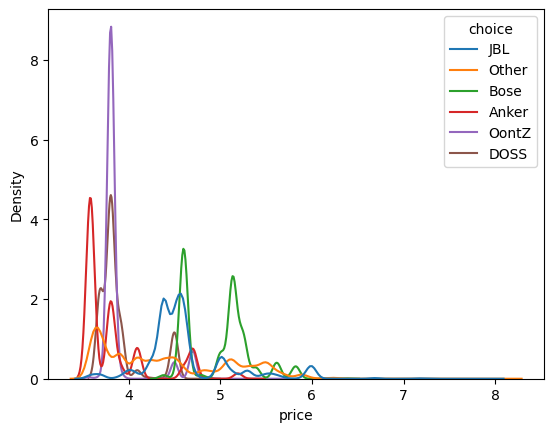

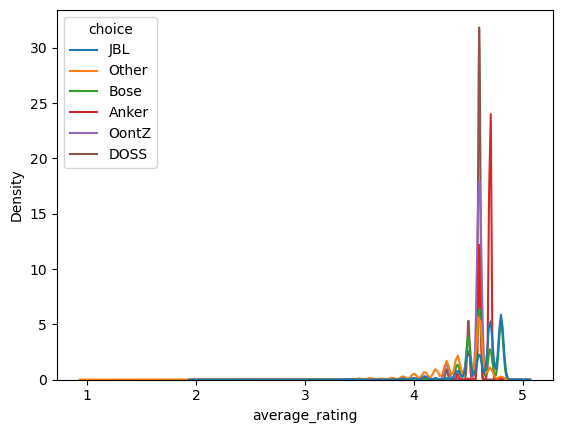

In [22]:
## EDA

sns.kdeplot(x=np.log(df['price']),hue=df['choice'], common_norm=False)
plt.show()

sns.kdeplot(x=df['average_rating'],hue=df['choice'], common_norm=False)
plt.show()


In [23]:

bdf = (
    df.groupby(['year', 'choice'], as_index=False)
      .agg(
          chosen_users=('user_id', 'nunique'),
          avg_price=('price', 'mean'),
          avg_rating=('average_rating', 'mean'),
          waterproof_share=('waterproof_flag', 'mean'),
          party_share=('party_flag', 'mean'),
          voice_assistant_share=('voice_assistant_flag', 'mean'),
      )
)

speaker_buyers = (
    bdf.groupby('year', as_index=False)['chosen_users']
      .sum()
      .rename(columns={'chosen_users': 'speaker_buyers'})
)

bdf = bdf.merge(speaker_buyers, on='year', how='left')
bdf['share_among_speaker_buyers'] = (
    bdf['chosen_users'] / bdf['speaker_buyers']
)

bdf.to_parquet('demand_2.parquet', engine='fastparquet')

bdf.head()



,year,choice,chosen_users,avg_price,avg_rating,waterproof_share,party_share,voice_assistant_share,speaker_buyers,share_among_speaker_buyers
0,2015,Anker,79,63.329873,4.529114,0.000000,0.000000,0.000000,20029,0.003944
1,2015,Bose,4212,141.189855,4.533974,0.000000,0.000000,0.000000,20029,0.210295
2,2015,JBL,2832,78.035332,4.383510,0.000353,0.000000,0.000000,20029,0.141395
3,2015,OontZ,104,45.456538,3.659615,0.000000,0.000000,0.903846,20029,0.005192
4,2015,Other,12802,134.215901,4.175402,0.060381,0.084596,0.028902,20029,0.639173


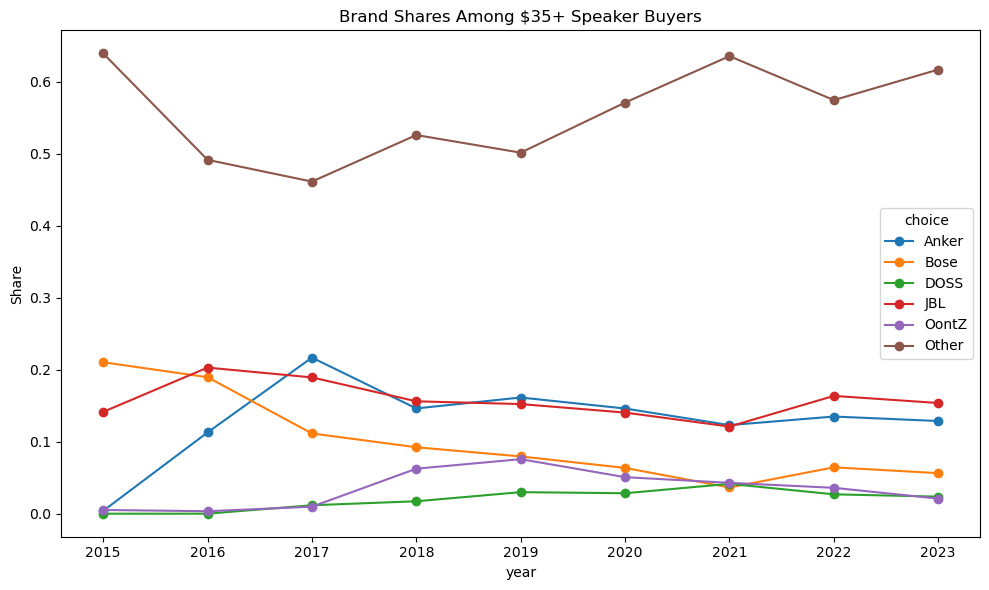

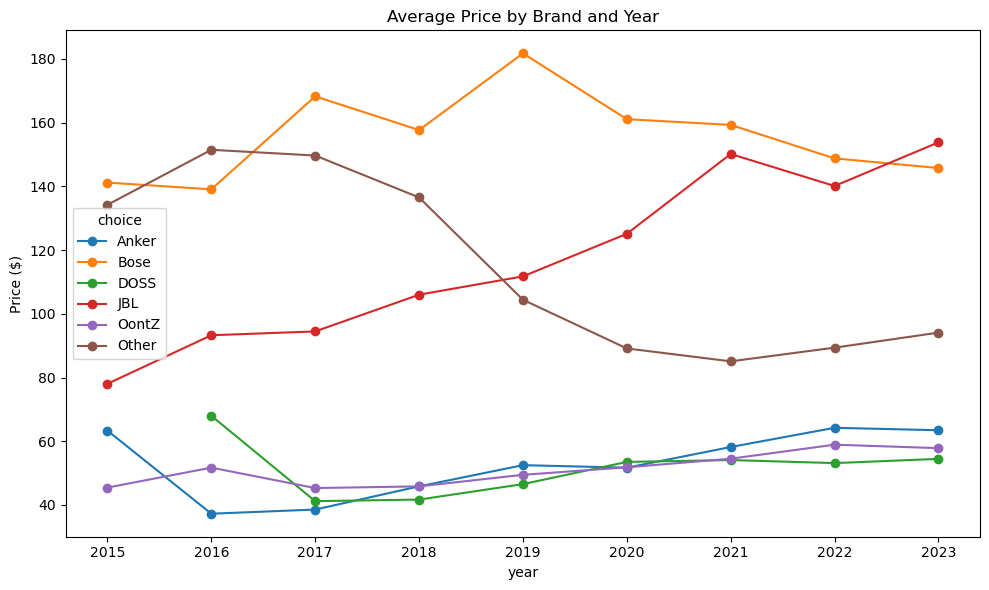

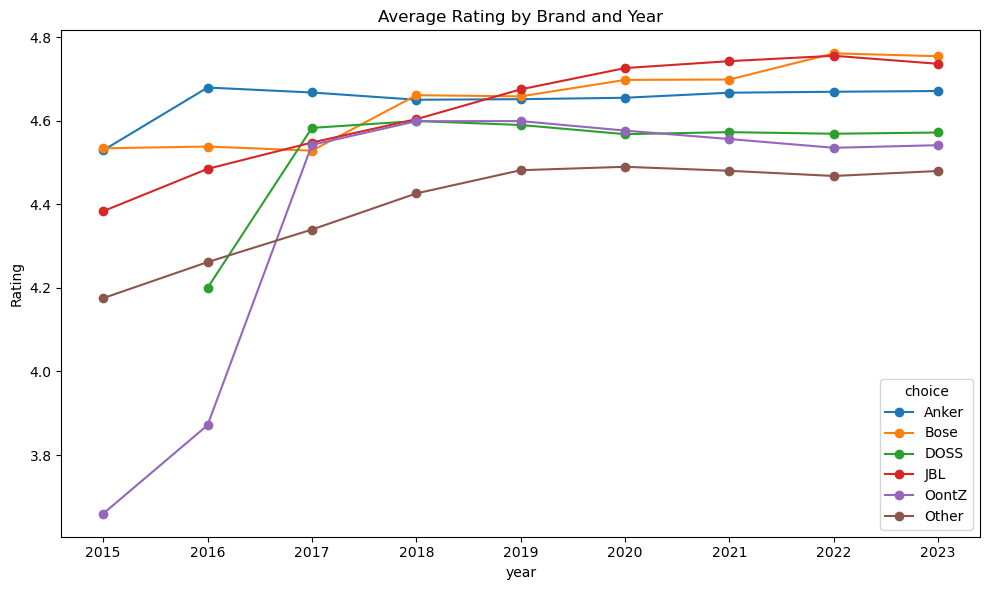

In [24]:
share_pivot = (
    bdf.pivot(index='year', columns='choice', values='share_among_speaker_buyers')
    .fillna(0)
)

price_pivot = (
    bdf.pivot(index='year', columns='choice', values='avg_price')
)


ratings_pivot = (
    bdf.pivot(index='year', columns='choice', values='avg_rating')
)

fig, ax = plt.subplots(figsize=(10, 6))
share_pivot.plot(marker='o', ax=ax)
ax.set_title('Brand Shares Among $35+ Speaker Buyers')
ax.set_ylabel('Share')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
price_pivot.plot(marker='o', ax=ax)
ax.set_title('Average Price by Brand and Year')
ax.set_ylabel('Price ($)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ratings_pivot.plot(marker='o', ax=ax)
ax.set_title('Average Rating by Brand and Year')
ax.set_ylabel('Rating')
plt.tight_layout()
plt.show()


In [25]:
base_choice = 'Other'

base_df = (
    bdf.loc[bdf['choice'] == base_choice, ['year', 'share_among_speaker_buyers']]
       .rename(columns={'share_among_speaker_buyers': 'base_share'})
)

reg_df = (
    bdf.loc[bdf['choice'] != base_choice]
       .merge(base_df, on='year', how='left')
       .copy()
)

reg_df['log_share_diff'] = (
    np.log(reg_df['share_among_speaker_buyers'].clip(lower=1e-12))
    - np.log(reg_df['base_share'].clip(lower=1e-12))
)

reg_df.to_parquet('demand_3.parquet', engine='fastparquet')

reg_df.head()

,year,choice,chosen_users,avg_price,avg_rating,waterproof_share,party_share,voice_assistant_share,speaker_buyers,share_among_speaker_buyers,base_share,log_share_diff
0,2015,Anker,79,63.329873,4.529114,0.000000,0.0,0.000000,20029,0.003944,0.639173,-5.087909
1,2015,Bose,4212,141.189855,4.533974,0.000000,0.0,0.000000,20029,0.210295,0.639173,-1.111664
2,2015,JBL,2832,78.035332,4.383510,0.000353,0.0,0.000000,20029,0.141395,0.639173,-1.508618
3,2015,OontZ,104,45.456538,3.659615,0.000000,0.0,0.903846,20029,0.005192,0.639173,-4.812966
4,2016,Anker,2982,37.254859,4.679376,0.000000,0.0,0.000000,26429,0.112831,0.491354,-1.471278


In [26]:
X = reg_df[
    ['avg_price', 'avg_rating', 'waterproof_share', 'party_share', 'voice_assistant_share']
].copy()

X = pd.concat(
    [
        X,
        pd.get_dummies(reg_df['choice'], prefix='choice', drop_first=True),
        pd.get_dummies(reg_df['year'], prefix='year', drop_first=True),
    ],
    axis=1,
)


y = reg_df['log_share_diff']

model = LinearRegression()
model.fit(X, y)

coef = pd.Series(model.coef_, index=X.columns).sort_values()
print(coef)

price_coef = float(pd.Series(model.coef_, index=X.columns)['avg_price'])
price_coef


waterproof_share        -3.839633
avg_price               -0.060613
year_2016                0.081771
year_2017                1.074972
year_2018                1.363930
year_2020                1.504579
year_2023                1.680606
choice_DOSS              1.745747
year_2021                1.838819
year_2019                2.051557
year_2022                2.141313
choice_OontZ             3.499626
voice_assistant_share    4.030405
choice_JBL               6.291683
choice_Bose              7.896362
avg_rating               9.036807
party_share              9.475497
dtype: float64


-0.06061346604245791

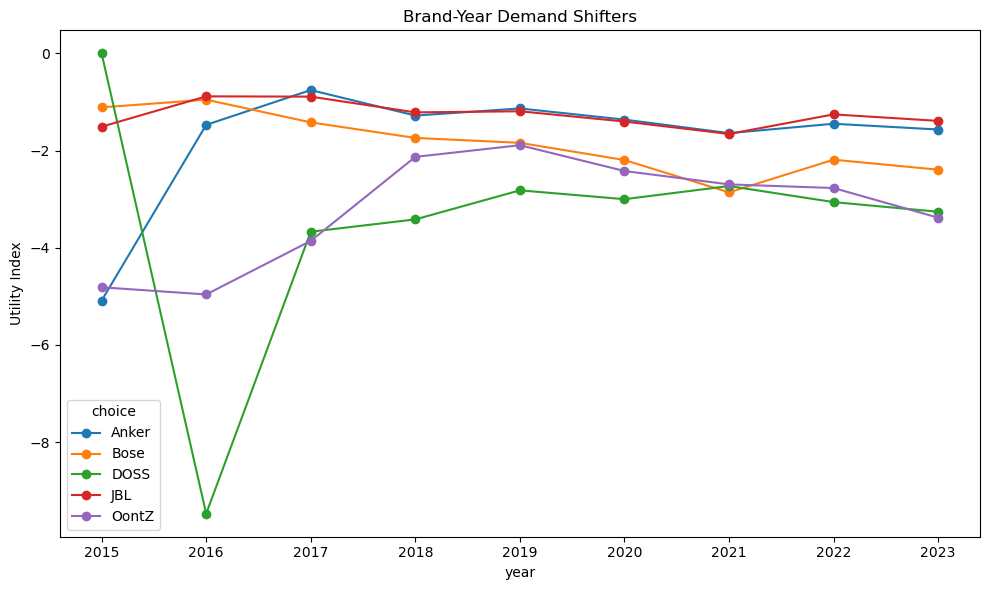

In [10]:
#reg_df['pred_delta'] = model.predict(X)
#reg_df['brand_year_shifter'] = reg_df['delta'] - price_coef * reg_df['avg_price']

shifter_pivot = reg_df.pivot(index='year', columns='choice', values='log_share_diff').fillna(0)
fig, ax = plt.subplots(figsize=(10, 6))
shifter_pivot.plot(marker='o', ax=ax)
ax.set_title('Brand-Year Demand Shifters')
ax.set_ylabel('Utility Index')
plt.tight_layout()
plt.show()

In [12]:
reg_df.head()

,year,choice,chosen_users,avg_price,avg_rating,waterproof_share,party_share,voice_assistant_share,speaker_buyers,share_among_speaker_buyers,base_share,log_share_diff,utility
0,2015,Anker,79,63.329873,4.529114,0.000000,0.0,0.000000,20029,0.003944,0.639173,-5.087909,-5.048407
1,2015,Bose,4212,141.189855,4.533974,0.000000,0.0,0.000000,20029,0.210295,0.639173,-1.111664,-1.827486
2,2015,JBL,2832,78.035332,4.383510,0.000353,0.0,0.000000,20029,0.141395,0.639173,-1.508618,-0.965224
3,2015,OontZ,104,45.456538,3.659615,0.000000,0.0,0.903846,20029,0.005192,0.639173,-4.812966,-4.680040
4,2016,Anker,2982,37.254859,4.679376,0.000000,0.0,0.000000,26429,0.112831,0.491354,-1.471278,-2.028247


In [13]:
# Predicted utility from the regression
reg_df = reg_df.copy()
reg_df['utility'] = model.predict(X)

# Price coefficient from the demand regression
price_coef = pd.Series(model.coef_, index=X.columns)['avg_price']

results = []

for year in reg_df['year'].unique():
    
    year_df = reg_df[reg_df['year'] == year].copy()
    
    # Total number of speaker buyers in that year
    buyers = float(bdf.loc[bdf['year'] == year, 'speaker_buyers'].iloc[0])
    
    # Predicted shares
    exp_utility = np.exp(year_df['utility'])
    denom = 1 + exp_utility.sum()
    year_df['share_inside'] = exp_utility / denom
    
    # Demand in number of users
    year_df['demand_users'] = buyers * year_df['share_inside']
    
    dprime_list = []
    
    for i in year_df.index:
        utility_plus = year_df['utility'].copy()
        utility_minus = year_df['utility'].copy()
        
        utility_plus.loc[i] += price_coef
        utility_minus.loc[i] -= price_coef
        
        share_plus = np.exp(utility_plus.loc[i]) / (1 + np.exp(utility_plus).sum())
        share_minus = np.exp(utility_minus.loc[i]) / (1 + np.exp(utility_minus).sum())
        
        dprime = buyers * (share_plus - share_minus) / 2
        dprime_list.append(dprime)
    
    year_df['dprime'] = dprime_list
    year_df['revenue'] = year_df['avg_price'] * year_df['demand_users']
    
    results.append(year_df)

econ = pd.concat(results, ignore_index=True)

econ = econ[[
    'year',
    'choice',
    'avg_price',
    'avg_rating',
    'share_among_speaker_buyers',
    'demand_users',
    'dprime',
    'revenue'
]].sort_values(['year', 'choice'])



econ.to_parquet('demand_3.parquet', engine='fastparquet')

econ.head()


,year,choice,avg_price,avg_rating,share_among_speaker_buyers,demand_users,dprime,revenue
0,2015,Anker,63.329873,4.529114,0.003944,82.558165,-4.986487,5228.398139
1,2015,Bose,141.189855,4.533974,0.210295,2068.180313,-112.445619,292006.078888
2,2015,JBL,78.035332,4.383510,0.141395,4898.509037,-224.283797,382256.778623
3,2015,OontZ,45.456538,3.659615,0.005192,119.327274,-7.193995,5424.204808
4,2016,Anker,37.254859,4.679376,0.112831,2187.746031,-121.670448,81504.170248


In [16]:

econ['elasticity'] = price_coef * econ['avg_price'] * (1 - econ['share_among_speaker_buyers'])
econ['markup'] = -econ['demand_users'] / econ['dprime']
econ['marginal_cost'] = econ['avg_price'] - econ['markup']
econ['profit'] = (econ['avg_price'] - econ['marginal_cost']) * econ['demand_users']

#econ[['year', 'choice', 'avg_price', 'demand_users', 'dprime', 'markup', 'marginal_cost', 'profit']].head(15)

econ.to_parquet('demand_4.parquet', engine='fastparquet')

econ.head(15)

,year,choice,avg_price,avg_rating,share_among_speaker_buyers,demand_users,dprime,revenue,elasticity,markup,marginal_cost,profit
0,2015,Anker,63.329873,4.529114,0.003944,82.558165,-4.986487,5228.398139,-3.823502,16.556379,46.773494,1366.864286
1,2015,Bose,141.189855,4.533974,0.210295,2068.180313,-112.445619,292006.078888,-6.758300,18.392716,122.797139,38039.452873
2,2015,JBL,78.035332,4.383510,0.141395,4898.509037,-224.283797,382256.778623,-4.061195,21.840673,56.194659,106986.733199
3,2015,OontZ,45.456538,3.659615,0.005192,119.327274,-7.193995,5424.204808,-2.740972,16.587066,28.869472,1979.289393
4,2016,Anker,37.254859,4.679376,0.112831,2187.746031,-121.670448,81504.170248,-2.003358,17.980915,19.273944,39337.676322
5,2016,Bose,139.076504,4.538219,0.189489,3427.594500,-180.849780,476697.858802,-6.832535,18.952716,120.123788,64962.224686
6,2016,DOSS,67.980000,4.200000,0.000038,25.584479,-1.550206,1739.232858,-4.120348,16.503921,51.476079,422.244223
7,2016,JBL,93.270425,4.484760,0.202845,4127.893559,-211.153793,385010.387796,-4.506669,19.549228,73.721198,80697.130872
8,2016,OontZ,51.715275,3.871429,0.003443,31.670691,-1.918536,1637.858487,-3.123849,16.507740,35.207534,522.811548
9,2017,Anker,38.560261,4.667531,0.216719,8820.592578,-375.814692,340124.351890,-1.830739,23.470590,15.089671,207024.512581


<Axes: xlabel='marginal_cost', ylabel='Density'>

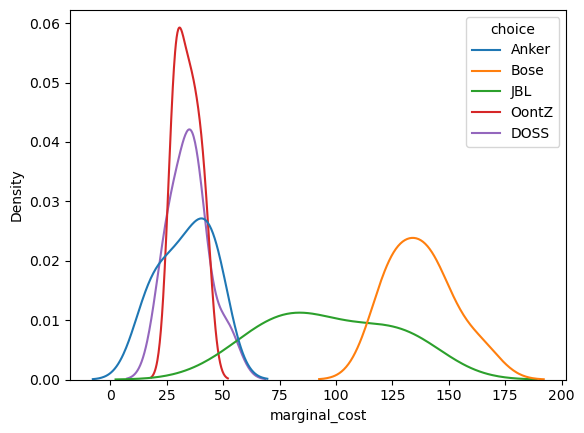

In [17]:
sns.kdeplot(x=econ['marginal_cost'],hue=econ['choice'], common_norm=False)

<Axes: xlabel='markup', ylabel='Density'>

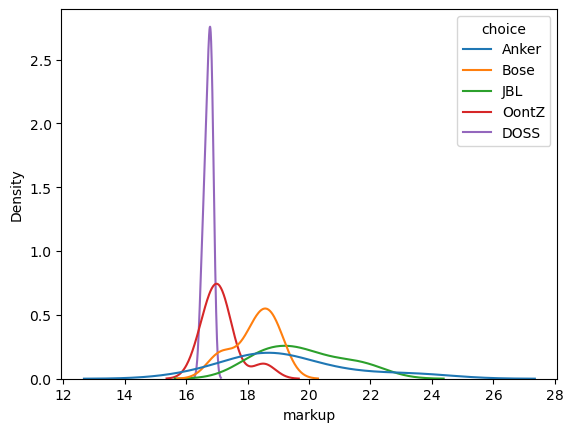

In [18]:
sns.kdeplot(x=econ['markup'],hue=econ['choice'], common_norm=False)

<Axes: xlabel='elasticity', ylabel='Density'>

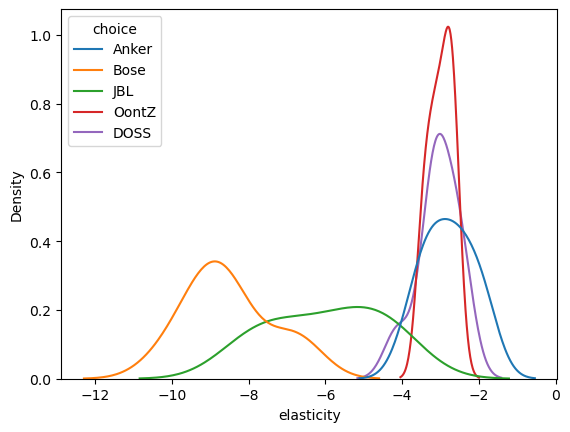

In [19]:
sns.kdeplot(x=econ['elasticity'],hue=econ['choice'], common_norm=False)

<Axes: xlabel='profit', ylabel='Density'>

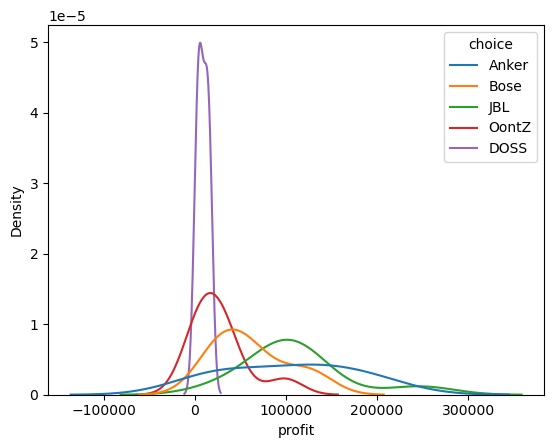

In [20]:
sns.kdeplot(x=econ['profit'],hue=econ['choice'], common_norm=False)